### Data Overview and Decompress
   
The initial dataset is too big, we should decide which column to keep which to drop, by observing the head, following decision is made.

The original columns are: overall (rating from 1-5), verified (user is verified or not), reviewTime, reviewerID, asin (product unique ID), style (the details feature of the product user bought), reviewerName, reviewText, summary, unixReviewTime, vote (how many people find it helpful)

Since not all features are strictly useful for our usecase, I kept the following column for this study only: overall, verified, asin, reviewText, summary.


1. Data Decompress and Feature Pre-Selection

Decompress by chunk and write only necessary columns into CSV file for pre-processing later.

Only keep when review exist and the length is >= 20 words. We end up with around 12.3M reviews after filtering, meaning the 20-word threshold removes roughly 40% of reviews that lack sufficient content.

In [9]:
import gzip, json
import pandas as pd
import os

CHUNK_SIZE = 50_000
OUTPUT_FILE = 'electronics_cleaned.csv'
PROGRESS_FILE = 'progress.txt'

# Read last processed line number
start_line = 0
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, 'r') as p:
        start_line = int(p.read().strip())
    print(f"Resuming from line {start_line}")
else:
    print("Starting fresh")

chunk = []
current_line = 0

with gzip.open('Electronics.json.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        current_line += 1
        if current_line <= start_line:
            continue  # skip already processed lines

        row = json.loads(line)
        text = row.get('reviewText')
        if not text or len(text.split()) <= 20:
            continue

        chunk.append({
            'asin': row.get('asin'),
            'overall': row.get('overall'),
            'reviewText': text,
            'summary': row.get('summary'),
            'verified': row.get('verified'),
        })

        if len(chunk) >= CHUNK_SIZE:
            write_header = not os.path.exists(OUTPUT_FILE)
            pd.DataFrame(chunk).to_csv(OUTPUT_FILE, mode='a', header=write_header, index=False)
            chunk = []
            # save progress
            with open(PROGRESS_FILE, 'w') as p:
                p.write(str(current_line))
            print(f"Saved up to line {current_line}")

# write remaining
if chunk:
    write_header = not os.path.exists(OUTPUT_FILE)
    pd.DataFrame(chunk).to_csv(OUTPUT_FILE, mode='a', header=write_header, index=False)

# clear progress file when done
os.remove(PROGRESS_FILE)
print("Done")

Starting fresh
Saved up to line 74752
Saved up to line 151572
Saved up to line 221621
Saved up to line 297348
Saved up to line 363878
Saved up to line 433078
Saved up to line 506812
Saved up to line 577180
Saved up to line 652311
Saved up to line 724926
Saved up to line 794743
Saved up to line 862354
Saved up to line 930665
Saved up to line 1005342
Saved up to line 1070995
Saved up to line 1133512
Saved up to line 1205079
Saved up to line 1274942
Saved up to line 1348119
Saved up to line 1416650
Saved up to line 1481798
Saved up to line 1544437
Saved up to line 1611950
Saved up to line 1679068
Saved up to line 1744978
Saved up to line 1814769
Saved up to line 1883452
Saved up to line 1949121
Saved up to line 2019575
Saved up to line 2084618
Saved up to line 2151126
Saved up to line 2221980
Saved up to line 2290226
Saved up to line 2355625
Saved up to line 2426609
Saved up to line 2491128
Saved up to line 2557942
Saved up to line 2630965
Saved up to line 2698441
Saved up to line 2766699

Check total number of reviews after pre-selection

In [4]:
import polars as pl
pl.scan_csv('electronics_cleaned.csv', schema_overrides={'asin': pl.Utf8}).select(pl.len()).collect()


len
u32
12274478


2. Data Filtering

Observe the reviews distribution per product, check whether most of the product do not have a significant number of reviews, if yes we need to drop them since they are not statistically significant. Use polars for streaming data.

/var/folders/7x/yhw3mdn55nb4mt_qj8_jpp4r0000gn/T/ipykernel_29453/2905180728.py:7: DeprecationWarning: `count` was renamed; use `len` instead
  review_counts = df.group_by('asin').count().collect()


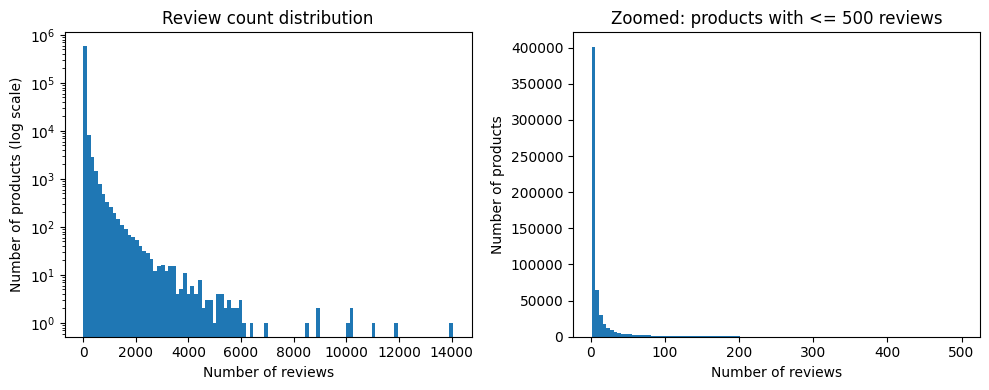

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 598103.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 20.522348  │
│ std        ┆ 115.316238 │
│ min        ┆ 1.0        │
│ 25%        ┆ 1.0        │
│ 50%        ┆ 3.0        │
│ 75%        ┆ 9.0        │
│ max        ┆ 14060.0    │
└────────────┴────────────┘
Products with >= 50 reviews: 41723
Products with >= 100 reviews: 22055
Products with >= 200 reviews: 10758


In [1]:
import matplotlib.pyplot as plt
import polars as pl

# Count reviews per product
df = pl.scan_csv('electronics_cleaned.csv', schema_overrides={'asin': pl.Utf8})

review_counts = df.group_by('asin').count().collect()

counts = review_counts['count'].to_numpy()
plt.figure(figsize=(10, 4))

# Full distribution
plt.subplot(1, 2, 1)
plt.hist(counts, bins=100, log=True)  # log scale to see tail
plt.xlabel('Number of reviews')
plt.ylabel('Number of products (log scale)')
plt.title('Review count distribution')

# Zoomed in to < 500 reviews to see the bulk
plt.subplot(1, 2, 2)
plt.hist(counts[counts <= 500], bins=100)
plt.xlabel('Number of reviews')
plt.ylabel('Number of products')
plt.title('Zoomed: products with <= 500 reviews')

plt.tight_layout()
plt.show()

# Summary stats
print(review_counts['count'].describe())
print(f"Products with >= 50 reviews: {(counts >= 50).sum()}")
print(f"Products with >= 100 reviews: {(counts >= 100).sum()}")
print(f"Products with >= 200 reviews: {(counts >= 200).sum()}")


3. Further filter out data

Based on statistic: 
- median review is 3 (most products have almost no reviews)
- 75th percentile is only 10 - vast majority of products are sparse
- Mean is 26 but std is 163 — heavily skewed by a few popular products with thousands of reviews

A threshold of 200 keeps 11k out of 721k products (~2%) but these will cover a disproportionately large share of total reviews - they are good for analysis. On top, we only randomly capped maximum 500 reviews per products, so that popular products do not dominate the study, also keep the dataset manageable

In [2]:
import polars as pl

df = pl.scan_csv('electronics_cleaned.csv', schema_overrides={'asin': pl.Utf8})

review_counts = df.group_by('asin').len().collect()
valid_asins = review_counts.filter(pl.col('len') >= 200)['asin']

df_filtered = df.filter(pl.col('asin').is_in(valid_asins)).collect()
print(f"Number of reviews after filtering: {len(df_filtered)}")

# Get number of products with >= 500 reviews
print(f"Number of products with >= 500 reviews: {review_counts.filter(pl.col('len') >= 500)['asin'].len()}")

# The result is 3442 — very few products have more than 500 reviews, but they can go up to 25k reviews. To prevent these outliers from dominating the dataset, we cap at 500 reviews per product. This is sufficient for sentiment distribution while reducing skewness.

df_sampled = df_filtered.group_by('asin').map_groups(
    lambda g: g.sample(n=min(500, len(g)), seed=42)
)

df_sampled.select([
    'asin', 'overall', 'reviewText', 'summary', 'verified'
]).write_csv('electronics_filtered.csv')

print("Done")

print(f"Number of reviews after filtering and sampling in total: {len(df_sampled)}")

/var/folders/7x/yhw3mdn55nb4mt_qj8_jpp4r0000gn/T/ipykernel_29453/1733038675.py:8: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = df.filter(pl.col('asin').is_in(valid_asins)).collect()


Number of reviews after filtering: 6025512
Number of products with >= 500 reviews: 3442
Done
Number of reviews after filtering and sampling in total: 3944626


After filtering and sampling, we have a total ~4M data points, with 11k products.

In [ ]:
import polars as pl
pl.scan_csv('electronics_filtered.csv', schema_overrides={'asin': pl.Utf8}).select(pl.len()).collect()

len
u32
3944626
